In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [6]:
import pandas as pd

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")
# sample_submission = pd.read_csv("/kaggle/input/playground-series-s5e12/sample_submission.csv")

train.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [7]:
#información general
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                

## 🧬 Contexto Clínico: ¿Por qué estas variables influyen en la diabetes?

La diabetes tipo 2 está fuertemente ligada a factores modificables como la alimentación, la actividad física y el peso corporal, así como a factores no modificables como la edad, el género o la herencia genética. Comprender la relevancia clínica de cada variable puede ayudarnos no solo a mejorar el modelo, sino también a interpretar sus resultados de forma responsable.

### **Edad (age)**
A mayor edad, mayor riesgo de desarrollar resistencia a la insulina.

### **Consumo de alcohol (alcohol_consumption_per_week)**
Un consumo excesivo puede alterar el metabolismo de la glucosa y contribuir a la obesidad.

### **Actividad física (physical_activity_minutes_per_week)**
El ejercicio mejora la sensibilidad a la insulina y reduce el riesgo de diabetes.

### **Diet Score (diet_score)**
Indica la calidad de la dieta. Una dieta equilibrada protege frente a cambios metabólicos.

### **Sueño (sleep_hours_per_day)**
Dormir muy poco o demasiado se asocia con desregulación hormonal y resistencia a la insulina.

### **Screen Time (screen_time_hours_per_day)**
Más horas frente a pantallas suele implicar sedentarismo.

### **IMC y cintura-cadera (bmi, waist_to_hip_ratio)**
Relacionados directamente con la obesidad abdominal, uno de los mayores factores de riesgo.

### **Presión arterial (systolic_bp, diastolic_bp)**
La hipertensión está estrechamente asociada al síndrome metabólico.

### **Colesterol y triglicéridos (hdl, ldl, total, triglycerides)**
Los desajustes en el perfil lipídico suelen acompañar a la diabetes tipo 2.

### **Género, etnia, nivel educativo, ingresos**
Variables sociodemográficas que pueden influir en estilos de vida y acceso a la salud.

### **Historial familiar (family_history_diabetes)**
La predisposición genética es un factor clave.

### **Hipertensión y enfermedades cardiovasculares**
Ambas condiciones suelen coexistir con la diabetes debido a mecanismos metabólicos comunes.

En conjunto, todas estas variables forman un mapa completo del estado de salud del paciente, ayudando al modelo a tomar decisiones más robustas y explicables.


## 📘 Diccionario de Datos (Extendido)

A continuación se presentan todas las variables del dataset, junto con ejemplos de valores posibles para facilitar su interpretación.

| Variable | Tipo | Traducción | Ejemplos de valores | Descripción |
|---------|------|------------|----------------------|-------------|
| id | int | Identificador | 0, 15233, 699999 | ID único de cada registro. |
| age | int | Edad | 18, 34, 62 | Edad del paciente. |
| alcohol_consumption_per_week | int | Consumo de alcohol semanal | 0, 5, 12 | Número de bebidas alcohólicas por semana. |
| physical_activity_minutes_per_week | int | Minutos actividad física | 0, 60, 150, 300 | Ejercicio semanal total. |
| diet_score | float | Puntuación de la dieta | 4.5, 7.2, 9.8 | A mayor valor, mejor calidad nutricional. |
| sleep_hours_per_day | float | Horas de sueño | 5.0, 7.5, 9.0 | Horas promedio dormidas al día. |
| screen_time_hours_per_day | float | Horas frente a pantallas | 2.0, 4.5, 8.0 | Tiempo diario usando ordenadores/móviles. |
| bmi | float | Índice de Masa Corporal | 21.3, 27.8, 33.2 | Peso relativo a la altura. |
| waist_to_hip_ratio | float | Relación cintura–cadera | 0.75, 0.85, 0.98 | Indicador de obesidad abdominal. |
| systolic_bp | int | Presión sistólica | 110, 130, 150 | Presión arterial alta. |
| diastolic_bp | int | Presión diastólica | 70, 85, 95 | Segundo número de la presión arterial. |
| heart_rate | int | Frecuencia cardíaca | 60, 72, 88 | Latidos por minuto. |
| cholesterol_total | int | Colesterol total | 150, 190, 220 | Lípidos totales en sangre. |
| hdl_cholesterol | int | Colesterol HDL | 40, 55, 75 | Colesterol “bueno”. |
| ldl_cholesterol | int | Colesterol LDL | 80, 120, 160 | Colesterol “malo”. |
| triglycerides | int | Triglicéridos | 80, 150, 250 | Grasa sanguínea. |
| gender | object | Género | "Male", "Female", "Other" | Identidad de género. |
| ethnicity | object | Etnia | "White", "Asian", "African American" | Origen étnico. |
| education_level | object | Nivel educativo | "High School", "Bachelor", "Master" | Formación académica. |
| income_level | object | Nivel de ingresos | "Low", "Medium", "High" | Rango económico. |
| smoking_status | object | Estado de fumador | "Never", "Former", "Current" | Hábito de fumar. |
| employment_status | object | Situación laboral | "Employed", "Unemployed", "Student" | Estado laboral actual. |
| family_history_diabetes | int | Historial familiar | 0, 1 | Indica si hay antecedentes. |
| hypertension_history | int | Historial hipertensión | 0, 1 | Antecedentes de presión alta. |
| cardiovascular_history | int | Historial cardiovascular | 0, 1 | Problemas del corazón previos. |
| diagnosed_diabetes | float | Diabetes diagnosticada | 0.0, 1.0 | Variable objetivo del modelo. |


In [8]:
# estadistica basica
train.describe()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000
mean,349999.500000,50.359734,2.072411,80.230803,5.963695,7.002200,6.012733,25.874684,0.858766,116.294193,75.440924,70.167749,186.818801,53.823214,102.905854,123.081850,0.149401,0.181990,0.030324,0.623296
std,202072.738554,11.655520,1.048189,51.195071,1.463336,0.901907,2.022707,2.860705,0.037980,11.010390,6.825775,6.938722,16.730832,8.266545,19.022416,24.739397,0.356484,0.385837,0.171478,0.484560
min,0.000000,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.000000,0.000000
25%,174999.750000,42.000000,1.000000,49.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,175.000000,48.000000,89.000000,106.000000,0.000000,0.000000,0.000000,0.000000
50%,349999.500000,50.000000,2.000000,71.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.000000,103.000000,123.000000,0.000000,0.000000,0.000000,1.000000
75%,524999.250000,58.000000,3.000000,96.000000,7.000000,7.600000,7.400000,27.800000,0.880000,124.000000,80.000000,75.000000,199.000000,59.000000,116.000000,139.000000,0.000000,0.000000,0.000000,1.000000
max,699999.000000,89.000000,9.000000,747.000000,9.900000,9.900000,16.500000,38.400000,1.050000,163.000000,104.000000,101.000000,289.000000,90.000000,205.000000,290.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", palette="viridis", rc={"figure.figsize":(12,6)})

In [6]:
# Diccionario para traducir columnas al español
traduccion = {
    'age': 'Edad',
    'alcohol_consumption_per_week': 'Consumo de alcohol semanal',
    'physical_activity_minutes_per_week': 'Minutos de actividad física/semana',
    'diet_score': 'Puntaje de dieta',
    'sleep_hours_per_day': 'Horas de sueño/día',
    'screen_time_hours_per_day': 'Horas frente a pantallas/día',
    'bmi': 'Índice de masa corporal (IMC)',
    'waist_to_hip_ratio': 'Relación cintura-cadera',
    'systolic_bp': 'Presión sistólica',
    'diastolic_bp': 'Presión diastólica',
    'heart_rate': 'Frecuencia cardíaca',
    'cholesterol_total': 'Colesterol total',
    'hdl_cholesterol': 'Colesterol HDL (bueno)',
    'ldl_cholesterol': 'Colesterol LDL (malo)',
    'triglycerides': 'Triglicéridos',
    'family_history_diabetes': 'Historial familiar de diabetes',
    'hypertension_history': 'Historial de hipertensión',
    'cardiovascular_history': 'Historial cardiovascular',
    'diagnosed_diabetes': 'Diabetes diagnosticada'
}


<Figure size 2000x2000 with 0 Axes>

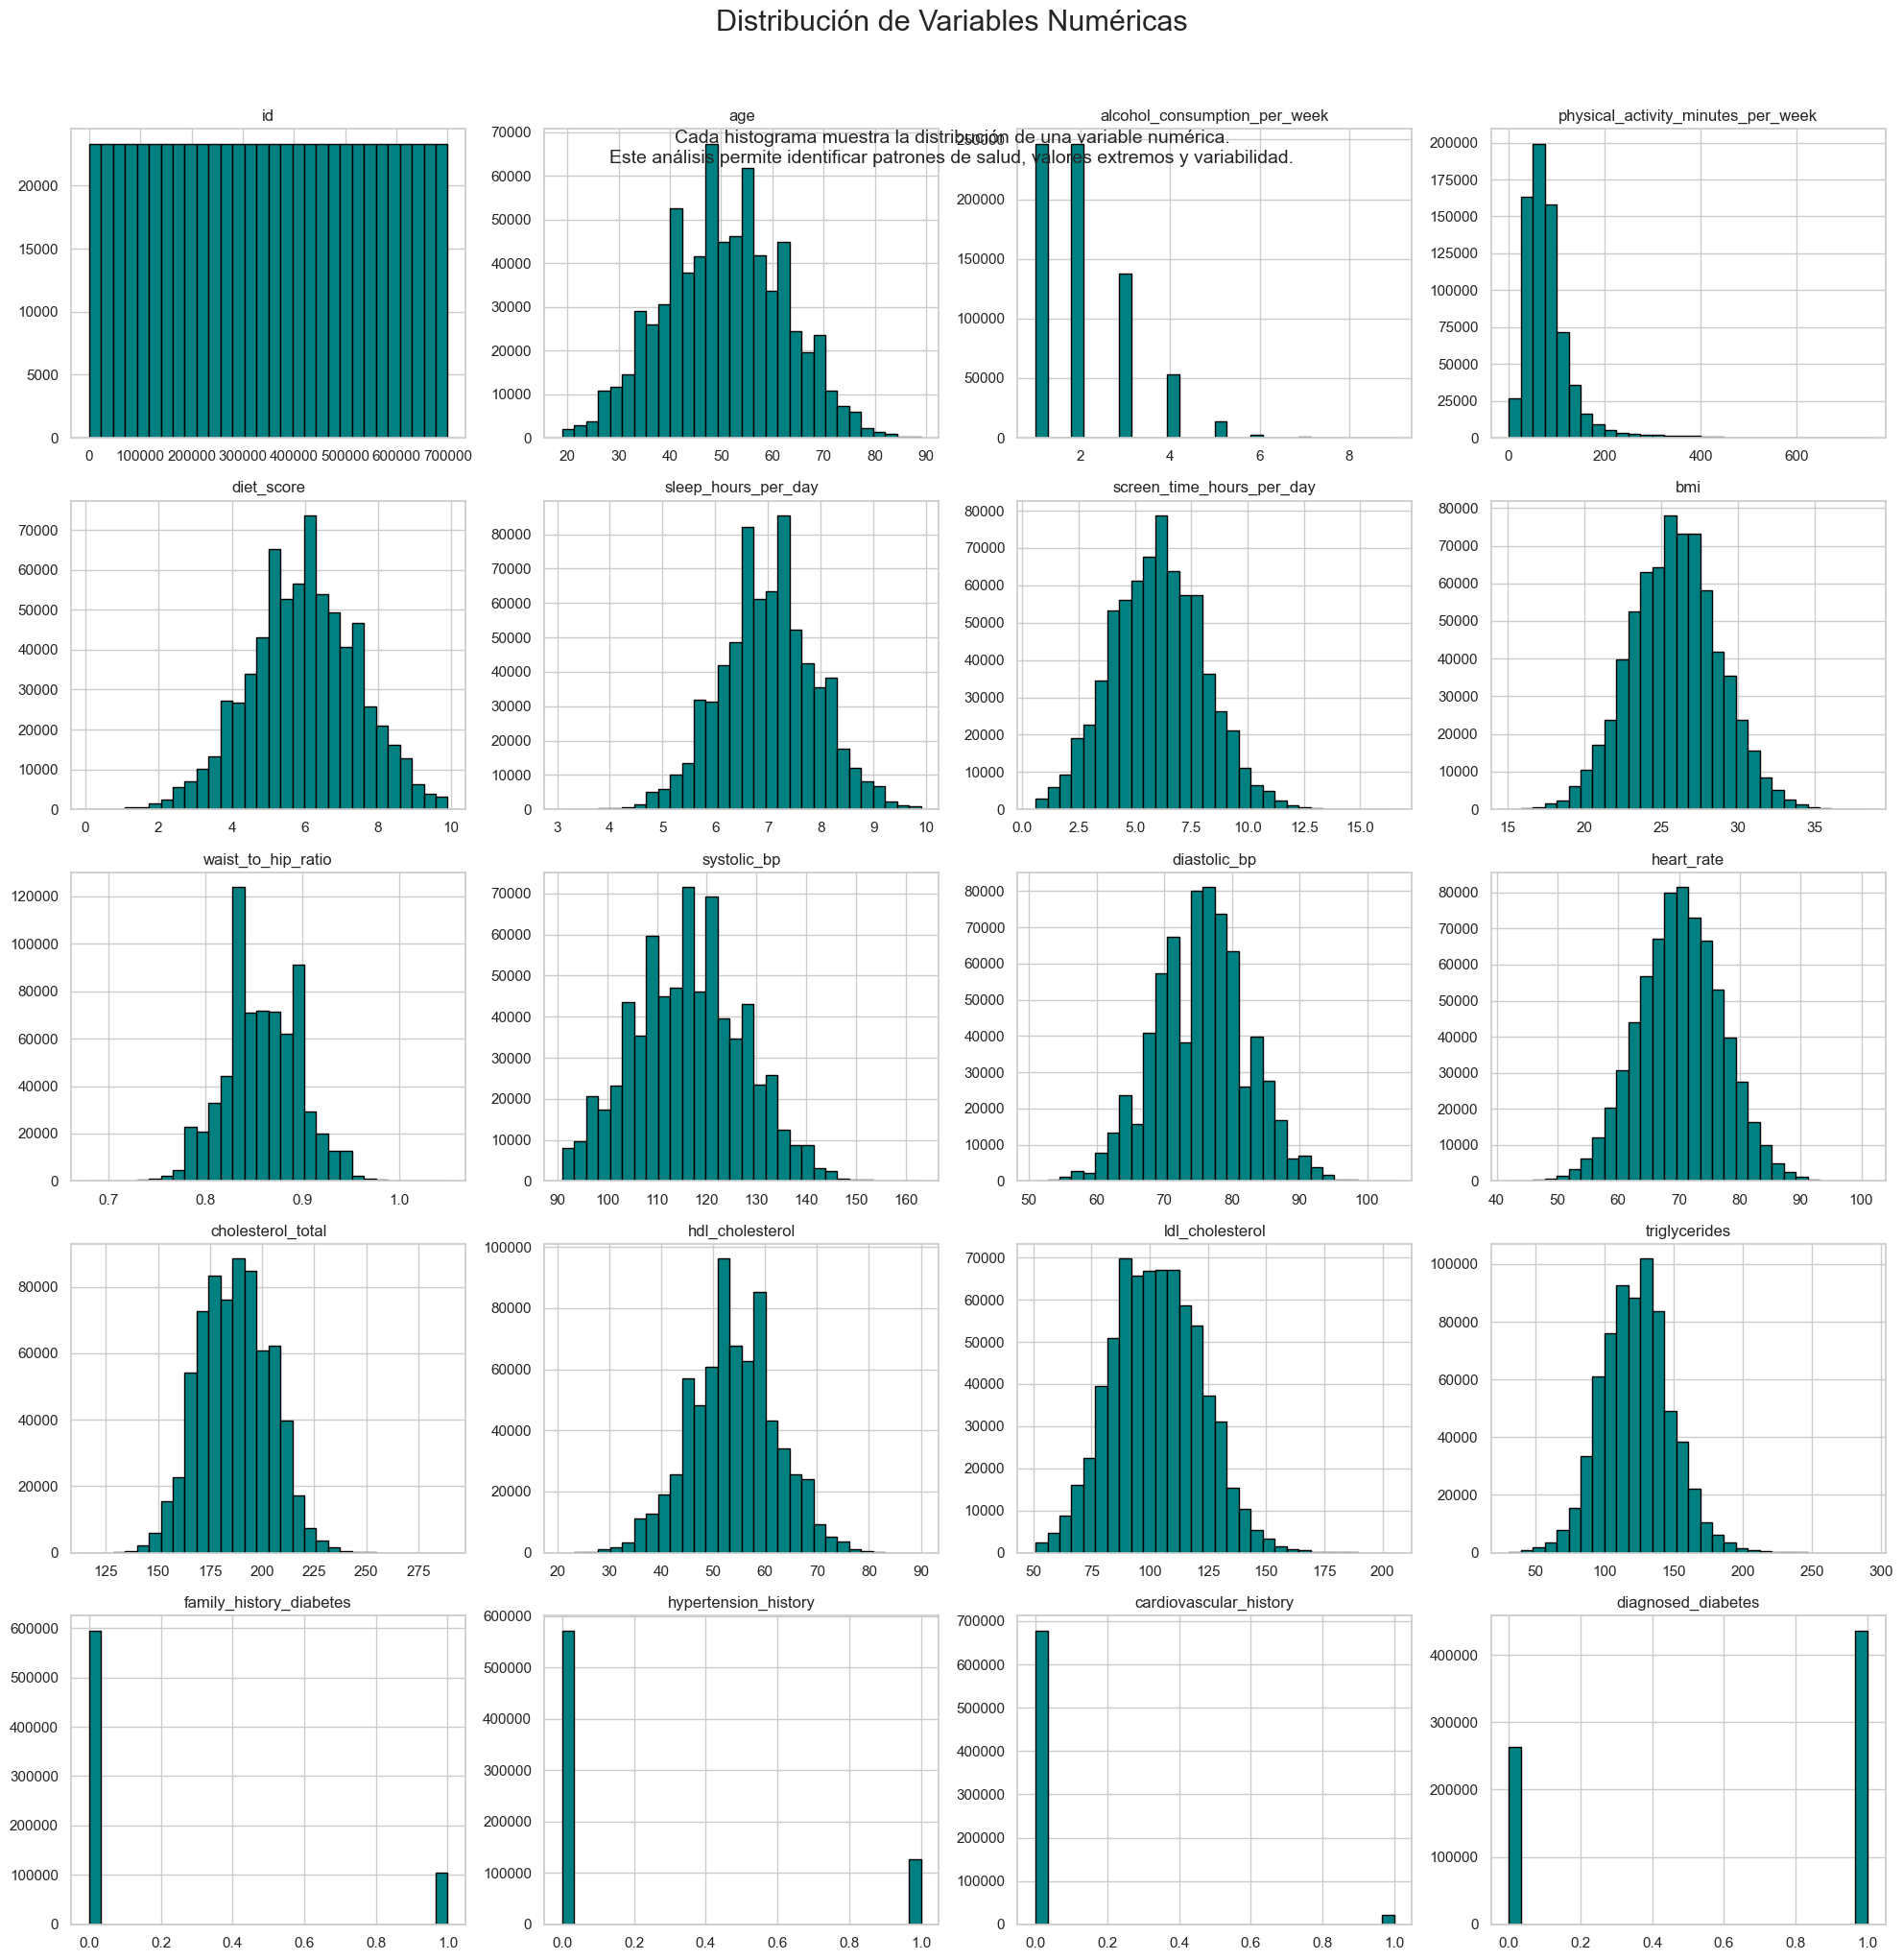

In [10]:


# Selección de columnas numéricas (excepto id)
num_cols = train.select_dtypes(include=['int64','float64']).columns.drop(['id'])

# Crear copia traduciendo nombres
# train_es = train[num_cols].rename(columns=traduccion)

plt.figure(figsize=(20,20))
train.hist(
    bins=30,
    figsize=(20,20),
    color='teal',
    edgecolor='black'
)

plt.suptitle("Distribución de Variables Numéricas", fontsize=22, y=1.02)

plt.figtext(
    0.5, 
    0.94,
    "Cada histograma muestra la distribución de una variable numérica.\n"
    "Este análisis permite identificar patrones de salud, valores extremos y variabilidad.",
    ha="center",
    fontsize=14
)

plt.tight_layout()
plt.show()






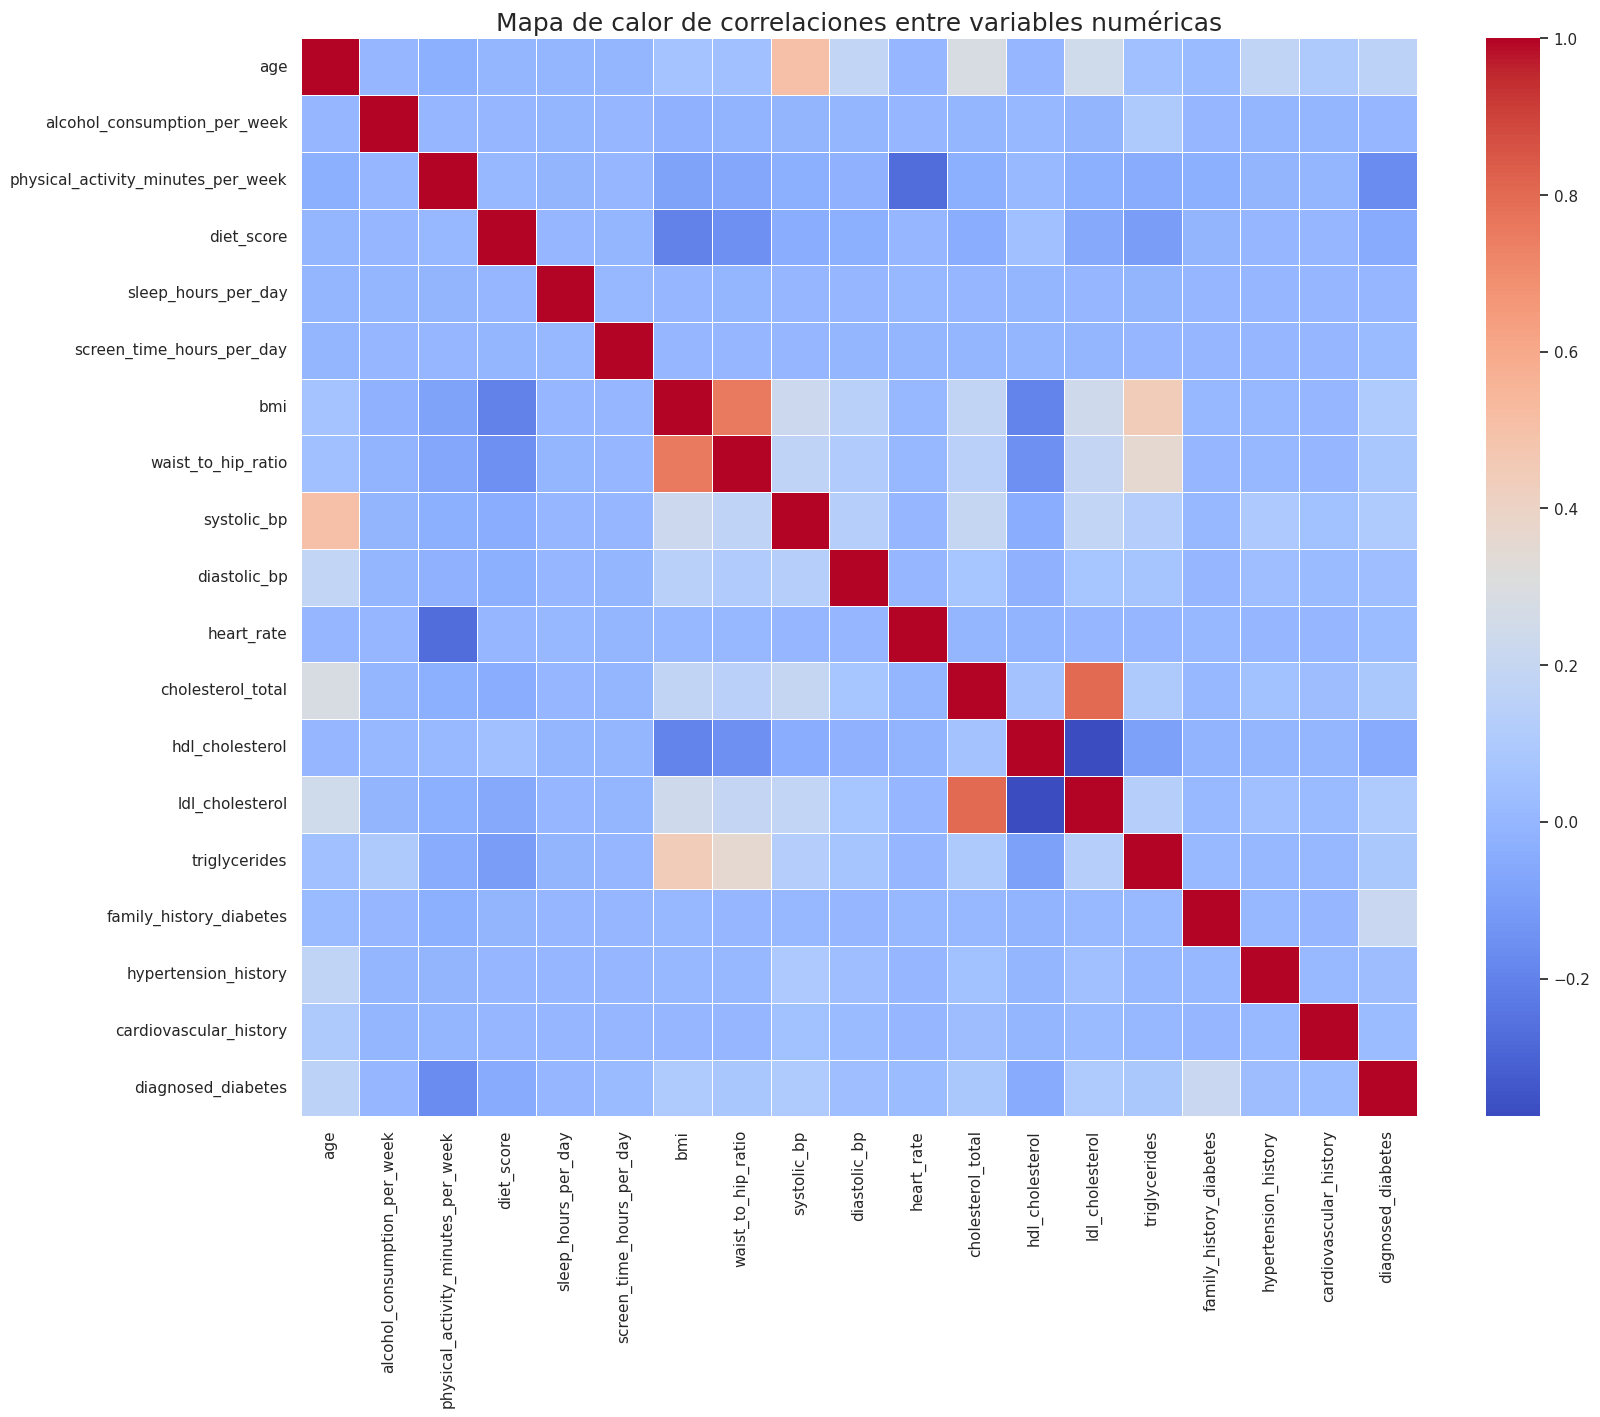

In [8]:


# Selección de columnas numéricas (sin id)
num_cols = train.select_dtypes(include=['int64','float64']).columns.drop(['id'])

# Matriz de correlación
corr = train[num_cols].corr()

plt.figure(figsize=(18,14))
sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False,
    linewidths=0.5
)
plt.title("Mapa de calor de correlaciones entre variables numéricas", fontsize=18)
plt.show()


In [9]:
target_corr = corr['diagnosed_diabetes'].abs().sort_values(ascending=False)
target_corr


diagnosed_diabetes                    1.000000
family_history_diabetes               0.211064
physical_activity_minutes_per_week    0.169789
age                                   0.161162
systolic_bp                           0.107132
bmi                                   0.105580
ldl_cholesterol                       0.102771
triglycerides                         0.090635
cholesterol_total                     0.088112
waist_to_hip_ratio                    0.081050
hdl_cholesterol                       0.053231
diet_score                            0.050119
diastolic_bp                          0.036271
hypertension_history                  0.029979
cardiovascular_history                0.024746
heart_rate                            0.023865
screen_time_hours_per_day             0.018213
sleep_hours_per_day                   0.003509
alcohol_consumption_per_week          0.002991
Name: diagnosed_diabetes, dtype: float64

## 🔍 Análisis de correlaciones con la diabetes

El análisis de correlación entre las variables numéricas y `diagnosed_diabetes` revela patrones clínicos claros y coherentes con la literatura médica sobre la diabetes tipo 2:

### 🥇 Factores con mayor correlación:
- **Historial familiar de diabetes (0.21):** El predictor más fuerte del dataset. La genética juega un papel clave en la predisposición a la diabetes.
- **Actividad física semanal (0.17):** La inactividad aumenta significativamente el riesgo.
- **Edad (0.16):** El riesgo crece con los años debido a la reducción de sensibilidad a la insulina.

### 🧬 Factores metabólicos importantes:
- **Presión sistólica (0.10)** y **IMC (0.105)**: Ambos están ligados al síndrome metabólico.
- **LDL (0.10), triglicéridos (0.09) y colesterol total (0.088):** Relacionados con alteraciones metabólicas propias de la diabetes tipo 2.
- **Relación cintura–cadera (0.081):** Indicador directo de obesidad abdominal.

### 🟡 Factores moderados:
- **HDL (0.053)** y **diet_score (0.050):** Un estilo de vida más saludable reduce el riesgo.

### ⚪ Factores con correlación débil:
- **Horas de sueño**, **alcohol semanal**, **screen time**: Mínimo impacto en este dataset concreto.

En conjunto, estas correlaciones ofrecen una visión clara de los factores clínicos y de estilo de vida más influyentes en el desarrollo de la diabetes.


Variables categóricas detectadas:
 ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']

Matriz de correlaciones creada con tamaño: (6, 6)


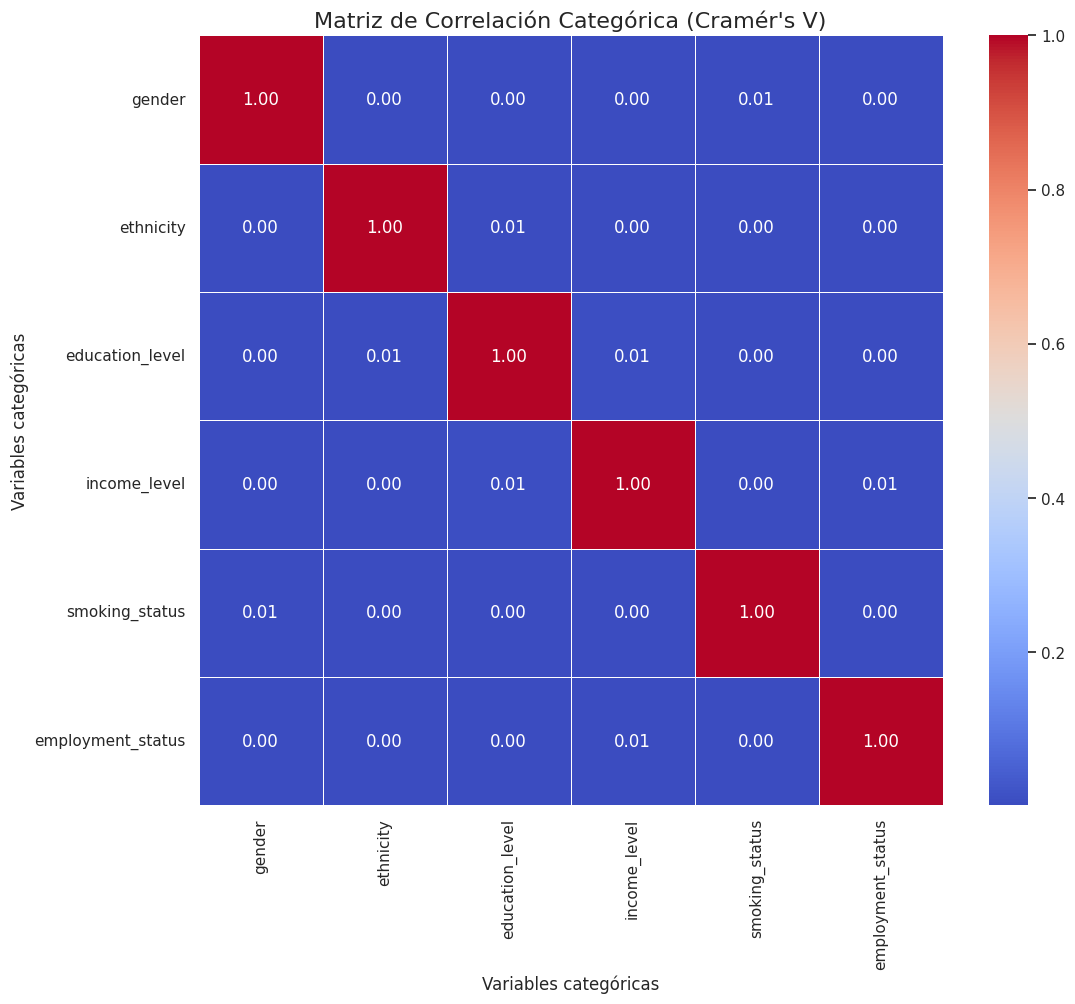

In [10]:
# ======================================
# CORRELACIÓN ENTRE VARIABLES CATEGÓRICAS (CRAMÉR'S V)
# ======================================


from scipy.stats import chi2_contingency

# --------------------------------------
# 1. Seleccionar variables categóricas
# --------------------------------------
cat_cols = train.select_dtypes(include=['object']).columns

print("Variables categóricas detectadas:\n", cat_cols.tolist())


# --------------------------------------
# 2. Función para calcular Cramér’s V
# --------------------------------------
def cramers_v(confusion_matrix):
    """
    Calcula Cramér's V a partir de una tabla cruzada.
    Devuelve un valor entre 0 y 1 indicando la fuerza de la asociación.
    """
    try:
        chi2 = chi2_contingency(confusion_matrix)[0]  # estadístico chi-cuadrado
        n = confusion_matrix.sum().sum()              # número de observaciones
        r, k = confusion_matrix.shape                 # dimensiones
        return np.sqrt(chi2 / (n * (min(r, k) - 1)))
    except:
        # Si algo falla (por ejemplo, una categoría vacía)
        return np.nan


# --------------------------------------
# 3. Crear matriz de correlaciones
# --------------------------------------
cramer_matrix = pd.DataFrame(
    np.zeros((len(cat_cols), len(cat_cols))),
    index=cat_cols,
    columns=cat_cols
)

# Confirmamos creación (para evitar NameError)
print("\nMatriz de correlaciones creada con tamaño:",
      cramer_matrix.shape)


# --------------------------------------
# 4. Calcular Cramér's V para cada par de variables
# --------------------------------------
for col1 in cat_cols:
    for col2 in cat_cols:
        tabla = pd.crosstab(train[col1], train[col2])
        cramer_matrix.loc[col1, col2] = cramers_v(tabla)


# --------------------------------------
# 5. Visualizar en un heatmap
# --------------------------------------
plt.figure(figsize=(12, 10))
sns.heatmap(
    cramer_matrix,
    annot=True,      # muestra valores
    fmt=".2f",       # formato de decimales
    cmap="coolwarm", # paleta de colores
    linewidths=0.5
)

plt.title("Matriz de Correlación Categórica (Cramér's V)", fontsize=16)
plt.xlabel("Variables categóricas")
plt.ylabel("Variables categóricas")
plt.show()


## 🔍 Por qué las variables categóricas muestran correlaciones bajas

El análisis con Cramér’s V muestra correlaciones bajas entre las variables categóricas y el diagnóstico de diabetes.  
Esto es completamente normal y esperado en este tipo de datasets clínicos.

### ✔ Factores sociodemográficos → correlación débil
Variables como género, etnia, nivel educativo, ingresos y situación laboral no miden directamente procesos biológicos.  
Influyen de manera indirecta en la salud (hábitos, acceso a recursos, estilo de vida), por lo que su relación estadística simple suele ser baja.

### ✔ Factores fisiológicos → correlación fuerte
En contraste, variables numéricas como índice de masa corporal, edad, presión arterial o colesterol están directamente relacionadas con los mecanismos metabólicos de la diabetes.  
Por eso sus correlaciones son mayores.

### ✔ Correlación baja ≠ irrelevancia
Aunque la correlación categórica es baja, estas variables pueden aportar información valiosa cuando actúan en conjunto dentro de un modelo predictivo.  
Algoritmos como Random Forest, Gradient Boosting o XGBoost capturan interacciones complejas que no se ven en el análisis univariable.

**Conclusión:**  
Las variables categóricas enriquecen el modelo, pero no deben esperarse correlaciones altas a nivel estadístico simple.


In [11]:
# vamos a contar cuántos casos hay en cada clase
train['diagnosed_diabetes'].value_counts()

diagnosed_diabetes
1.0    436307
0.0    263693
Name: count, dtype: int64

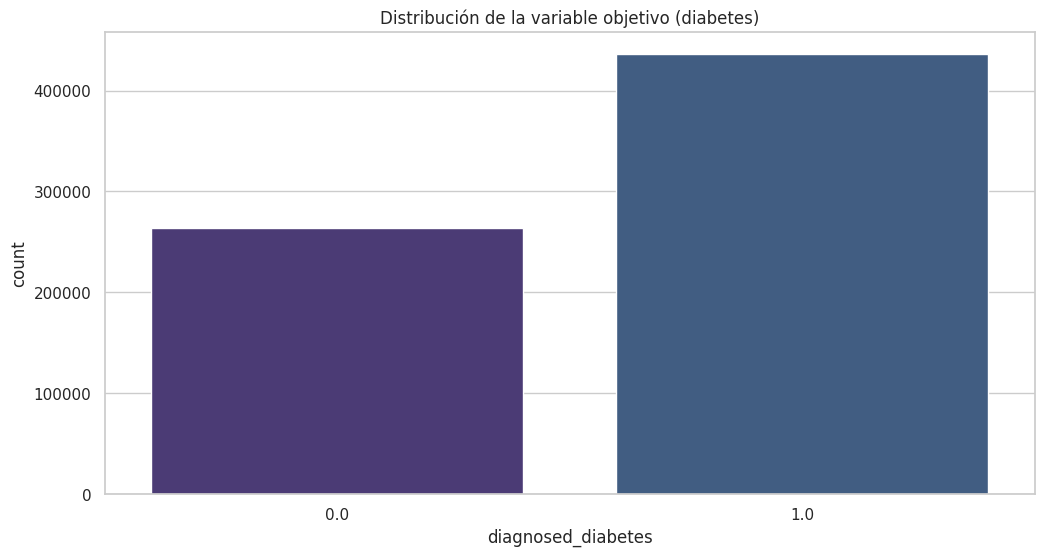

In [12]:
sns.countplot(data=train, x='diagnosed_diabetes')
plt.title('Distribución de la variable objetivo (diabetes)')
plt.show()

## 📌 Selección de Características usando Mutual Information

La **Mutual Information (MI)** es una técnica que permite identificar cuánto “sabe” cada variable sobre la variable objetivo, incluso cuando la relación no es lineal.
A diferencia de la correlación de Pearson, MI puede **detectar interacciones complejas y dependencias que no son evidentes a simple vista**.

La utilizamos para:

**descubrir variables con alto poder predictivo**

**capturar patrones no lineales**

**complementar la selección basada en correlación**

**obtener una visión más completa de qué variables aportan información real al modelo**

A continuación, calcularemos la MI para todas las características del dataset, tanto numéricas como categóricas (previamente codificadas). Esto nos permitirá obtener un ranking de importancia basado en la información que cada feature comparte con la variable diagnosed_diabetes.

In [13]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

df = train.copy()

# Codificamos categóricas
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

X = df.drop('diagnosed_diabetes', axis=1)
y = df['diagnosed_diabetes']

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_scores = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

mi_scores.head(20)


smoking_status                        0.059889
ethnicity                             0.040792
physical_activity_minutes_per_week    0.035526
family_history_diabetes               0.034215
education_level                       0.033757
income_level                          0.029587
gender                                0.027591
alcohol_consumption_per_week          0.016303
age                                   0.015974
waist_to_hip_ratio                    0.010291
triglycerides                         0.009127
systolic_bp                           0.008846
hypertension_history                  0.008213
ldl_cholesterol                       0.006950
bmi                                   0.006503
cholesterol_total                     0.005863
employment_status                     0.004405
heart_rate                            0.004050
diastolic_bp                          0.003994
sleep_hours_per_day                   0.003328
dtype: float64

## Interpretación del ranking generado por Mutual Information
1-.smoking_status — 0.0599

2-.ethnicity — 0.0408

3-.physical_activity_minutes_per_week — 0.0355

fumar y la etnia aparecen como factores con dependencia compleja con la diabetes, aunque tenían muy poca correlación lineal.Esto es **EXACTAMENTE** por lo que usamos MI.

### Conclusión importante 
**Pearson** detecta bien factores biométricos (bmi, age, systolic_bp)

**MI** detecta bien factores sociodemográficos y de estilo de vida (ethnicity, smoking_status, education_level)

## 🌲 Importancia de características usando Random Forest

El modelo Random Forest permite evaluar la importancia de cada variable analizando cuántas veces y con qué eficacia es utilizada para dividir los árboles durante el entrenamiento.  
Este método es especialmente útil porque detecta relaciones no lineales e interacciones entre variables que otros métodos (como la correlación o la Mutual Information) pueden pasar por alto.

Calcularemos la importancia basándonos en un Random Forest con `class_weight='balanced'` para compensar el desbalanceo de clases en el dataset. Posteriormente, ordenaremos las variables según su contribución al modelo para identificar las más relevantes.


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Copia del dataset
df = train.copy()

# Codificar categóricas
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Selección de muestra para acelerar el cálculo
df_sample = df.sample(80000, random_state=42)

X = df_sample.drop('diagnosed_diabetes', axis=1)
y = df_sample['diagnosed_diabetes']

# Entrenar el modelo
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf.fit(X, y)

# Importancia de features
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=False)

importances_sorted.head(20)


physical_activity_minutes_per_week    0.085514
age                                   0.064789
id                                    0.063166
triglycerides                         0.058489
bmi                                   0.058071
screen_time_hours_per_day             0.056325
diet_score                            0.054622
ldl_cholesterol                       0.054316
cholesterol_total                     0.052713
systolic_bp                           0.051887
sleep_hours_per_day                   0.050722
hdl_cholesterol                       0.049097
family_history_diabetes               0.048524
heart_rate                            0.048402
diastolic_bp                          0.047973
waist_to_hip_ratio                    0.037562
income_level                          0.020803
alcohol_consumption_per_week          0.020414
ethnicity                             0.017609
education_level                       0.015641
dtype: float64

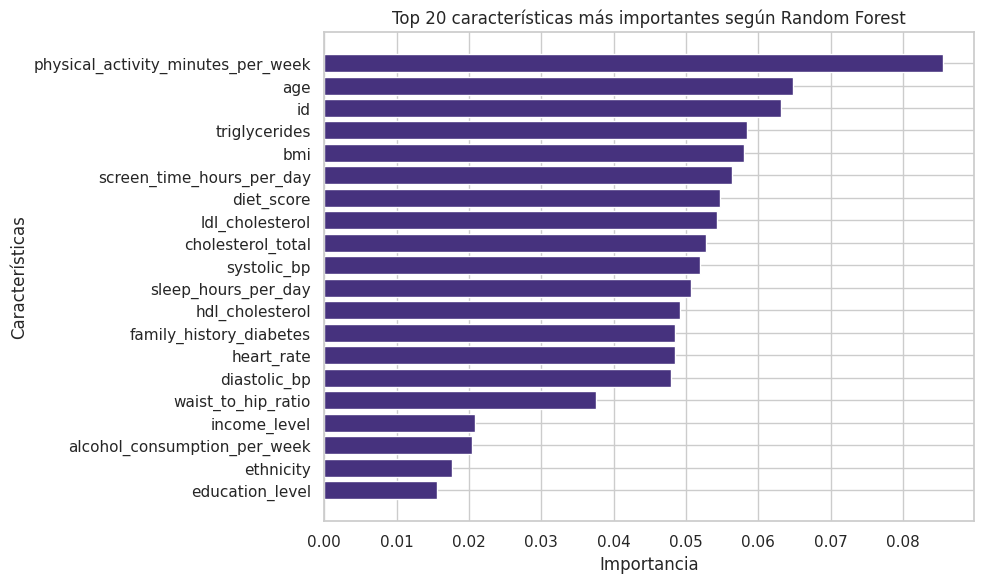

In [15]:
# Nos quedamos con el Top 20
top_n = 20
feat_importances = importances_sorted.head(top_n)

plt.figure(figsize=(10, 6))

# Gráfico de barras horizontal para mejor legibilidad
plt.barh(feat_importances.index, feat_importances.values)

plt.gca().invert_yaxis()  # Para que la más importante quede arriba
plt.title('Top 20 características más importantes según Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Características')

plt.tight_layout()
plt.show()

## 🧼 Preprocesado de datos

Antes de entrenar cualquier modelo de predicción de diabetes, es fundamental realizar un preprocesado adecuado de los datos.  
En esta sección vamos a:

1. Seleccionar únicamente las características más relevantes (features) identificadas en el análisis previo.
2. Separar la variable objetivo (`diagnosed_diabetes`) de las variables explicativas.
3. Dividir el conjunto de datos en entrenamiento y prueba, manteniendo el balance de clases mediante estratificación.
4. Aplicar un preprocesado diferenciado:
   - Estandarización de variables numéricas.
   - Codificación *one-hot* de variables categóricas.

De esta forma, garantizamos que los datos estén en un formato adecuado para que los modelos de machine learning puedan aprender patrones de forma eficiente y sin sesgos derivados de las escalas o de las categorías.


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# 1. Definimos la variable objetivo
target = 'diagnosed_diabetes'

# 2. Lista de características seleccionadas (sin 'id')
selected_features = [
    'physical_activity_minutes_per_week',
    'age',
    'family_history_diabetes',
    'bmi',
    'triglycerides',
    'systolic_bp',
    'cholesterol_total',
    'ldl_cholesterol',
    'waist_to_hip_ratio',
    'hdl_cholesterol',
    'diet_score',
    'screen_time_hours_per_day',
    'sleep_hours_per_day',
    'heart_rate',
    'diastolic_bp',
    'smoking_status',
    'ethnicity',
    'education_level',
    'income_level',
    'gender'
]

# 3. Creamos X e y
X = train[selected_features].copy()
y = train[target]

# 4. Identificamos variables numéricas y categóricas dentro de X
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Variables numéricas:", num_features)
print("Variables categóricas:", cat_features)

# 5. Dividimos en entrenamiento y prueba con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 6. Definimos los transformadores para numéricas y categóricas
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# 7. Creamos el ColumnTransformer para aplicar el preprocesado
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# (Opcional) 8. Definimos un pipeline base con solo el preprocesador
# Más adelante añadiremos el modelo (LogisticRegression, RandomForest, etc.)
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

# Ajustamos el preprocesador usando solo los datos de entrenamiento
baseline_pipeline.fit(X_train)

print("✅ Preprocesado completado: escalado numérico y one-hot en categóricas.")


Variables numéricas: ['physical_activity_minutes_per_week', 'age', 'family_history_diabetes', 'bmi', 'triglycerides', 'systolic_bp', 'cholesterol_total', 'ldl_cholesterol', 'waist_to_hip_ratio', 'hdl_cholesterol', 'diet_score', 'screen_time_hours_per_day', 'sleep_hours_per_day', 'heart_rate', 'diastolic_bp']
Variables categóricas: ['smoking_status', 'ethnicity', 'education_level', 'income_level', 'gender']
✅ Preprocesado completado: escalado numérico y one-hot en categóricas.


## 🚀 Modelo Baseline: Regresión Logística

Como primer modelo de referencia, entrenamos una **Regresión Logística** utilizando el preprocesador definido previamente.  
Este modelo es ideal como baseline porque:

- Es interpretable.
- Maneja bien relaciones lineales.
- Es muy rápido de entrenar.
- Permite el uso de `class_weight='balanced'`, lo cual compensa el desbalance de clases en el dataset.

Evaluaremos su desempeño usando métricas clave:
- Accuracy  
- Precision  
- Recall  
- F1-score  
- ROC-AUC  
- Matriz de confusión  

Estos resultados nos permitirán comparar el rendimiento de modelos más avanzados en pasos posteriores.


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Pipeline completo: preprocesado + modelo
logreg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=500,
        solver='liblinear'  # robusto para datasets grandes
    ))
])

# Entrenamos
logreg_model.fit(X_train, y_train)

print("✅ Modelo de Regresión Logística entrenado correctamente.")


✅ Modelo de Regresión Logística entrenado correctamente.


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predicciones
y_pred = logreg_model.predict(X_test)
y_proba = logreg_model.predict_proba(X_test)[:, 1]

# Métricas
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("📌 Resultados del modelo baseline (Regresión Logística):")
print(f"Accuracy:        {acc:.4f}")
print(f"Precision:       {prec:.4f}")
print(f"Recall:          {rec:.4f}")
print(f"F1-score:        {f1:.4f}")
print(f"ROC-AUC:         {roc_auc:.4f}")

📌 Resultados del modelo baseline (Regresión Logística):
Accuracy:        0.6272
Precision:       0.7545
Recall:          0.5957
F1-score:        0.6658
ROC-AUC:         0.6948


# Matriz de confusión

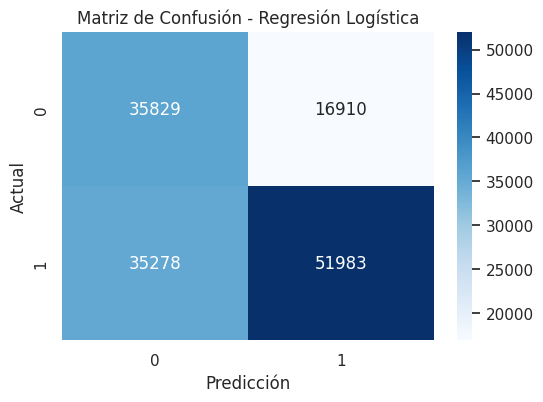

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Actual")
plt.show()


# Curva ROC-AUC

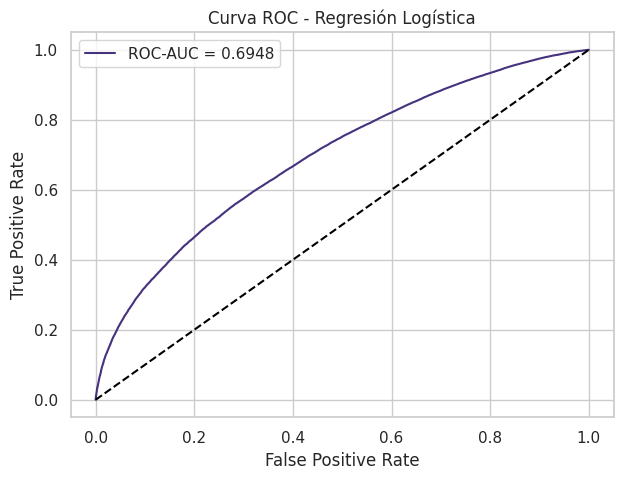

In [20]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.4f}')
plt.plot([0,1], [0,1], 'k--')  # línea diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Regresión Logística')
plt.legend()
plt.grid(True)
plt.show()
